In [1]:
# This program was original made by following along with Codemy.com tutorials on YouTube.
# Playlist here:
# https://youtube.com/playlist?list=PLCC34OHNcOtpcgR9LEYSdi9r7XIbpkpK1&si=qN9cA47jvIpXJ6Ez

# It has since been modified for use with the NASA Turbofan Jet Engine Data Set for a Machine Learning in ME course at UC Berkeley.

In [2]:
import torch # Import the PyTorch library
import torch.nn as nn # Import the neural network module from PyTorch for defining layers and loss functions
import torch.nn.functional as F # Import functional interface for operations like activation functions (ReLU)

In [3]:
# Create a Model Class that inherits nn.Module, the base class for all neural network modules in PyTorch
class Model(nn.Module):
  # Input layer (24 features of the Engine) -->
  # Hidden Layer1 (number of neurons) --> 128
  # H2 (n) --> 64
  # H3 (n) --> 32
  # H4 (n) --> 16
  # output (1 value for RUL prediction)
  def __init__(self, in_features=24, h1=128, h2=64, h3=32, h4=16, out_features=1, dropout=0.2):
    super().__init__() # instantiate our nn.Module, initializing the parent class
    self.fc1 = nn.Linear(in_features, h1) # Define the first fully connected (linear) layer: input -> h1
    #self.bn1 = nn.BatchNorm1d(h1) # Add batch normalization after fc1
    self.fc2 = nn.Linear(h1, h2) # Define the second fully connected layer: h1 -> h2
    #self.bn2 = nn.BatchNorm1d(h2) # Add batch normalization after fc2
    self.fc3 = nn.Linear(h2, h3) # Define the third fully connected layer: h2 -> h3
    #self.bn3 = nn.BatchNorm1d(h3) # Add batch normalization after fc3
    self.fc4 = nn.Linear(h3, h4) # Define the fourth fully connected layer: h3 -> h4
    #self.bn4 = nn.BatchNorm1d(h4) # Add batch normalization after fc4
    self.out = nn.Linear(h4, out_features) # Define the output layer: h4 -> output
    #self.dropout = nn.Dropout(dropout) # Dropout layer

  # Define the forward pass, which dictates how data moves through the network
  def forward(self, x):
    x = self.fc1(x) # Pass through fc1
    #x = self.bn1(x) # Apply batch normalization
    #x = F.relu(x) # Apply ReLU activation
    x = F.gelu(x) # Apply GELU activation
    #x = self.dropout(x) # Apply dropout
    
    x = self.fc2(x) # Pass through fc2
    #x = self.bn2(x) # Apply batch normalization
    x = F.gelu(x) # Apply GELU activation
    #x = F.gelu(x) # Apply GELU activation
    #x = self.dropout(x) # Apply dropout
    
    x = self.fc3(x) # Pass through fc3
    #x = self.bn3(x) # Apply batch normalization
    x = F.gelu(x) # Apply GELU activation
    #x = F.gelu(x) # Apply GELU activation
    #x = self.dropout(x) # Apply dropout
    
    x = self.fc4(x) # Pass through fc4
    #x = self.bn4(x) # Apply batch normalization
    x = F.gelu(x) # Apply GELU activation
    #x = F.gelu(x) # Apply GELU activation
    #x = self.dropout(x) # Apply dropout
    
    x = self.out(x) # Pass result through the output layer (no activation on output for regression)

    return x # Return the final output

In [4]:
# Pick a manual seed for randomization so results are reproducible
torch.manual_seed(69)
# Create an instance of our defined Model class
model = Model()

In [5]:
import pandas as pd # Import pandas for data manipulation (DataFrames)
import matplotlib.pyplot as plt # Import matplotlib for plotting graphs
# Magic command to display plots directly in the notebook cells
%matplotlib inline

In [6]:
Training_df = pd.read_csv('Train3.csv') # Load the CSV data from the Train1.csv file into a pandas DataFrame

In [7]:
Training_df.tail()

,engine,cycle,op_set1,op_set2,op_set3,Fan Inlet Temperature,LPC Outlet Temperature,HPC Outlet Temperature,LPT Outlet Temperature,Fan Inlet Pressure,...,Corrected Fan Speed,Corrected Core Speed,Bypass Ratio,Burner Fuel-Air Ratio,Bleed Enthalpy,Required Fan Speed,Required Fan Conversion Speed,High-Pressure Turbines Cool Air Flow,Low-Pressure Turbines Cool Air Flow,RUL
24715,100,148,-0.0016,-0.0003,100.0,518.67,643.78,1596.01,1424.11,14.62,...,2388.30,8138.08,8.5036,0.03,394,2388,100.0,38.44,22.9631,4.0
24716,100,149,0.0034,-0.0003,100.0,518.67,643.29,1596.38,1429.14,14.62,...,2388.28,8144.36,8.5174,0.03,395,2388,100.0,38.50,22.9746,3.0
24717,100,150,-0.0016,0.0004,100.0,518.67,643.84,1604.53,1431.41,14.62,...,2388.24,8135.95,8.5223,0.03,396,2388,100.0,38.39,23.0682,2.0
24718,100,151,-0.0023,0.0004,100.0,518.67,643.94,1597.56,1426.57,14.62,...,2388.26,8141.24,8.5148,0.03,395,2388,100.0,38.31,23.0753,1.0
24719,100,152,0.0000,0.0003,100.0,518.67,643.64,1599.04,1436.06,14.62,...,2388.24,8136.98,8.5150,0.03,396,2388,100.0,38.56,23.0847,0.0


In [8]:
import numpy as np
from sklearn.preprocessing import MinMaxScaler

# Separate the feature columns (columns 3-26, which are indices 2-25 in 0-indexed)
feature_columns = Training_df.columns[2:26]  # This gets columns from index 2 to 25 (columns 3-26)

# Initialize the MinMaxScaler
scaler = MinMaxScaler()

# Scale the feature columns to [0, 1]
Training_df[feature_columns] = scaler.fit_transform(Training_df[feature_columns])

print("Features scaled successfully!")
print(f"\nScaled data preview:")
print(Training_df.head())
print(f"\nMin values:\n{Training_df[feature_columns].min()}")
print(f"\nMax values:\n{Training_df[feature_columns].max()}")


Features scaled successfully!

Scaled data preview:
   engine  cycle   op_set1   op_set2  op_set3  Fan Inlet Temperature  \
0       1      1  0.470930  0.769231      0.0                    0.0   
1       1      2  0.546512  0.230769      0.0                    0.0   
2       1      3  0.418605  0.307692      0.0                    0.0   
3       1      4  0.383721  0.538462      0.0                    0.0   
4       1      5  0.593023  0.461538      0.0                    0.0   

   LPC Outlet Temperature  HPC Outlet Temperature  LPT Outlet Temperature  \
0                0.355972                0.370523                0.308580   
1                0.388759                0.399100                0.309360   
2                0.313817                0.353298                0.445398   
3                0.487119                0.417107                0.237285   
4                0.196721                0.476218                0.321217   

   Fan Inlet Pressure  ...  Corrected Fan Speed  Cor

In [9]:
# Train Test Split!  Set X, y
X = Training_df.drop(['engine', 'cycle', 'RUL'], axis=1) # Create features matrix X by dropping the target column 'variety'
y = Training_df['RUL'] # Create target vector y containing only the 'variety' column

In [10]:
# Convert these pandas objects to numpy arrays for compatibility with PyTorch or further processing
X = X.values
y = y.values

In [11]:
# Load and process the test data
Testing_df = pd.read_csv('Test3.csv')

# Scale the test data features using the SAME scaler fitted on training data
Testing_df[feature_columns] = scaler.transform(Testing_df[feature_columns])

# Separate features and target for test data
X_test_data = Testing_df.drop(['engine', 'cycle', 'RUL'], axis=1)
y_test_data = Testing_df['RUL']

# Convert to numpy arrays
X_test_data = X_test_data.values
y_test_data = y_test_data.values

# Establish Training and Testing sets
X_train = X  # Training features
y_train = y  # Training targets
X_test = X_test_data  # Testing features
y_test = y_test_data  # Testing targets

print(f"Training set: {X_train.shape} samples")
print(f"Testing set: {X_test.shape} samples")


Training set: (24720, 24) samples
Testing set: (16596, 24) samples


In [12]:
# Convert X features to float tensors, which are the standard data type for inputs in PyTorch
X_train = torch.FloatTensor(X_train)
X_test = torch.FloatTensor(X_test)


In [13]:
# Convert y labels to float tensors for regression (not LongTensor for classification)
y_train = torch.FloatTensor(y_train)
y_test = torch.FloatTensor(y_test)


In [14]:
# Set the criterion of model to measure the error, how far off the predictions are from the data
criterion = nn.MSELoss() # MSELoss (Mean Squared Error) is used for regression tasks
# Choose Adam Optimizer, lr = learning rate (if error doesn't go down after a bunch of iterations (epochs), lower our learning rate)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01) # Initialize optimizer to update model weights based on gradients


In [15]:
# Train our model!
# Epochs? (one run thru all the training data in our network)
epochs = 1000 # Define number of training iterations
losses = [] # List to store loss values for plotting later
for i in range(epochs): # Loop through the number of epochs
  # Go forward and get a prediction
  y_pred = model.forward(X_train) # Get predicted results by passing training data through the model

  # Measure the loss/error, gonna be high at first
  loss = criterion(y_pred.squeeze(), y_train) # Calculate loss by comparing predictions (y_pred) vs actual values (y_train)

  # Keep Track of our losses
  losses.append(loss.detach().numpy()) # Detach loss from graph to save memory and convert to numpy for storing

  # print every 10 epoch
  if i % 10 == 0:
    print(f'Epoch: {i} and loss: {loss}')

  # Do some back propagation: take the error rate of forward propagation and feed it back
  # thru the network to fine tune the weights
  optimizer.zero_grad() # Clear previous gradients
  loss.backward() # Calculate gradients (backpropagation)
  optimizer.step() # Update weights using the optimizer


Epoch: 0 and loss: 28889.076171875
Epoch: 10 and loss: 25067.302734375
Epoch: 20 and loss: 12343.3525390625
Epoch: 30 and loss: 11651.50390625
Epoch: 40 and loss: 9738.0546875
Epoch: 50 and loss: 8058.86328125
Epoch: 60 and loss: 5765.55224609375
Epoch: 70 and loss: 4034.81201171875
Epoch: 80 and loss: 3973.977294921875
Epoch: 90 and loss: 3839.762451171875
Epoch: 100 and loss: 3801.299072265625
Epoch: 110 and loss: 3752.544677734375
Epoch: 120 and loss: 3725.763427734375
Epoch: 130 and loss: 3696.113037109375
Epoch: 140 and loss: 3670.430419921875
Epoch: 150 and loss: 3647.258544921875
Epoch: 160 and loss: 3626.95263671875
Epoch: 170 and loss: 3609.311279296875
Epoch: 180 and loss: 3593.900390625
Epoch: 190 and loss: 3579.999755859375
Epoch: 200 and loss: 3567.01806640625
Epoch: 210 and loss: 3554.6513671875
Epoch: 220 and loss: 3542.936279296875
Epoch: 230 and loss: 3532.114013671875
Epoch: 240 and loss: 3522.36962890625
Epoch: 250 and loss: 3513.793212890625
Epoch: 260 and loss: 350

Text(0.5, 0, 'Epoch')

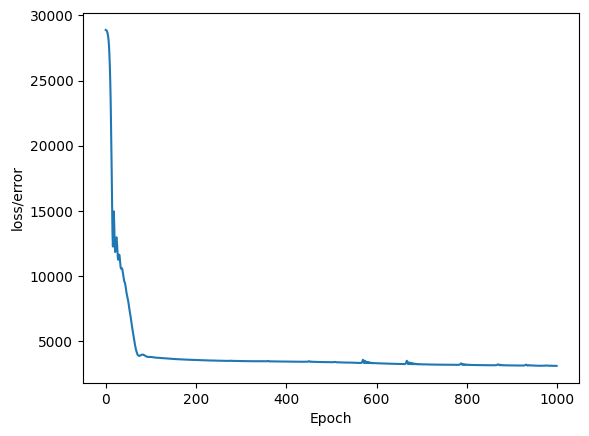

In [16]:
# Graph it out!
plt.plot(range(epochs), losses) # Plot the loss values over epochs
plt.ylabel("loss/error") # Label the y-axis
plt.xlabel('Epoch') # Label the x-axis

In [17]:
# Evaluate Model on Test Data Set (validate model on test set)
with torch.no_grad():  # Basically turn off back propogation (gradient calculation) to save memory and computation
  y_eval = model.forward(X_test) # X_test are features from our test set, y_eval will be predictions
  loss = criterion(y_eval.squeeze(), y_test) # Find the loss or error on the test set

print(f'Test Loss (MSE): {loss.item():.4f}')


Test Loss (MSE): 4664.7954


In [18]:
model.eval()  # Set model to evaluation mode
correct = 0
with torch.no_grad(): # Disable gradient calculation
  for i, data in enumerate(X_test): # Iterate over test data
    y_val = model.forward(data.unsqueeze(0)) # Add batch dimension: (24,) -> (1, 24)

    # Will tell us what RUL our network predicts
    print(f'{i+1}.)  Predicted: {y_val.item():.2f} \t Actual: {y_test[i].item():.2f}')

# Calculate accuracy metrics for regression
with torch.no_grad():
  y_pred_all = model.forward(X_test)
  mae = torch.mean(torch.abs(y_pred_all.squeeze() - y_test))
  print(f'\nMean Absolute Error: {mae.item():.2f}')

1.)  Predicted: 234.77 	 Actual: 276.00
2.)  Predicted: 227.52 	 Actual: 275.00
3.)  Predicted: 212.50 	 Actual: 274.00
4.)  Predicted: 228.34 	 Actual: 273.00
5.)  Predicted: 227.83 	 Actual: 272.00
6.)  Predicted: 202.50 	 Actual: 271.00
7.)  Predicted: 231.10 	 Actual: 270.00
8.)  Predicted: 199.27 	 Actual: 269.00
9.)  Predicted: 232.00 	 Actual: 268.00
10.)  Predicted: 215.49 	 Actual: 267.00
11.)  Predicted: 249.31 	 Actual: 266.00
12.)  Predicted: 224.82 	 Actual: 265.00
13.)  Predicted: 217.80 	 Actual: 264.00
14.)  Predicted: 221.81 	 Actual: 263.00
15.)  Predicted: 222.70 	 Actual: 262.00
16.)  Predicted: 238.79 	 Actual: 261.00
17.)  Predicted: 225.35 	 Actual: 260.00
18.)  Predicted: 197.87 	 Actual: 259.00
19.)  Predicted: 230.36 	 Actual: 258.00
20.)  Predicted: 229.48 	 Actual: 257.00
21.)  Predicted: 209.70 	 Actual: 256.00
22.)  Predicted: 213.33 	 Actual: 255.00
23.)  Predicted: 226.68 	 Actual: 254.00
24.)  Predicted: 213.76 	 Actual: 253.00
25.)  Predicted: 220.56 	

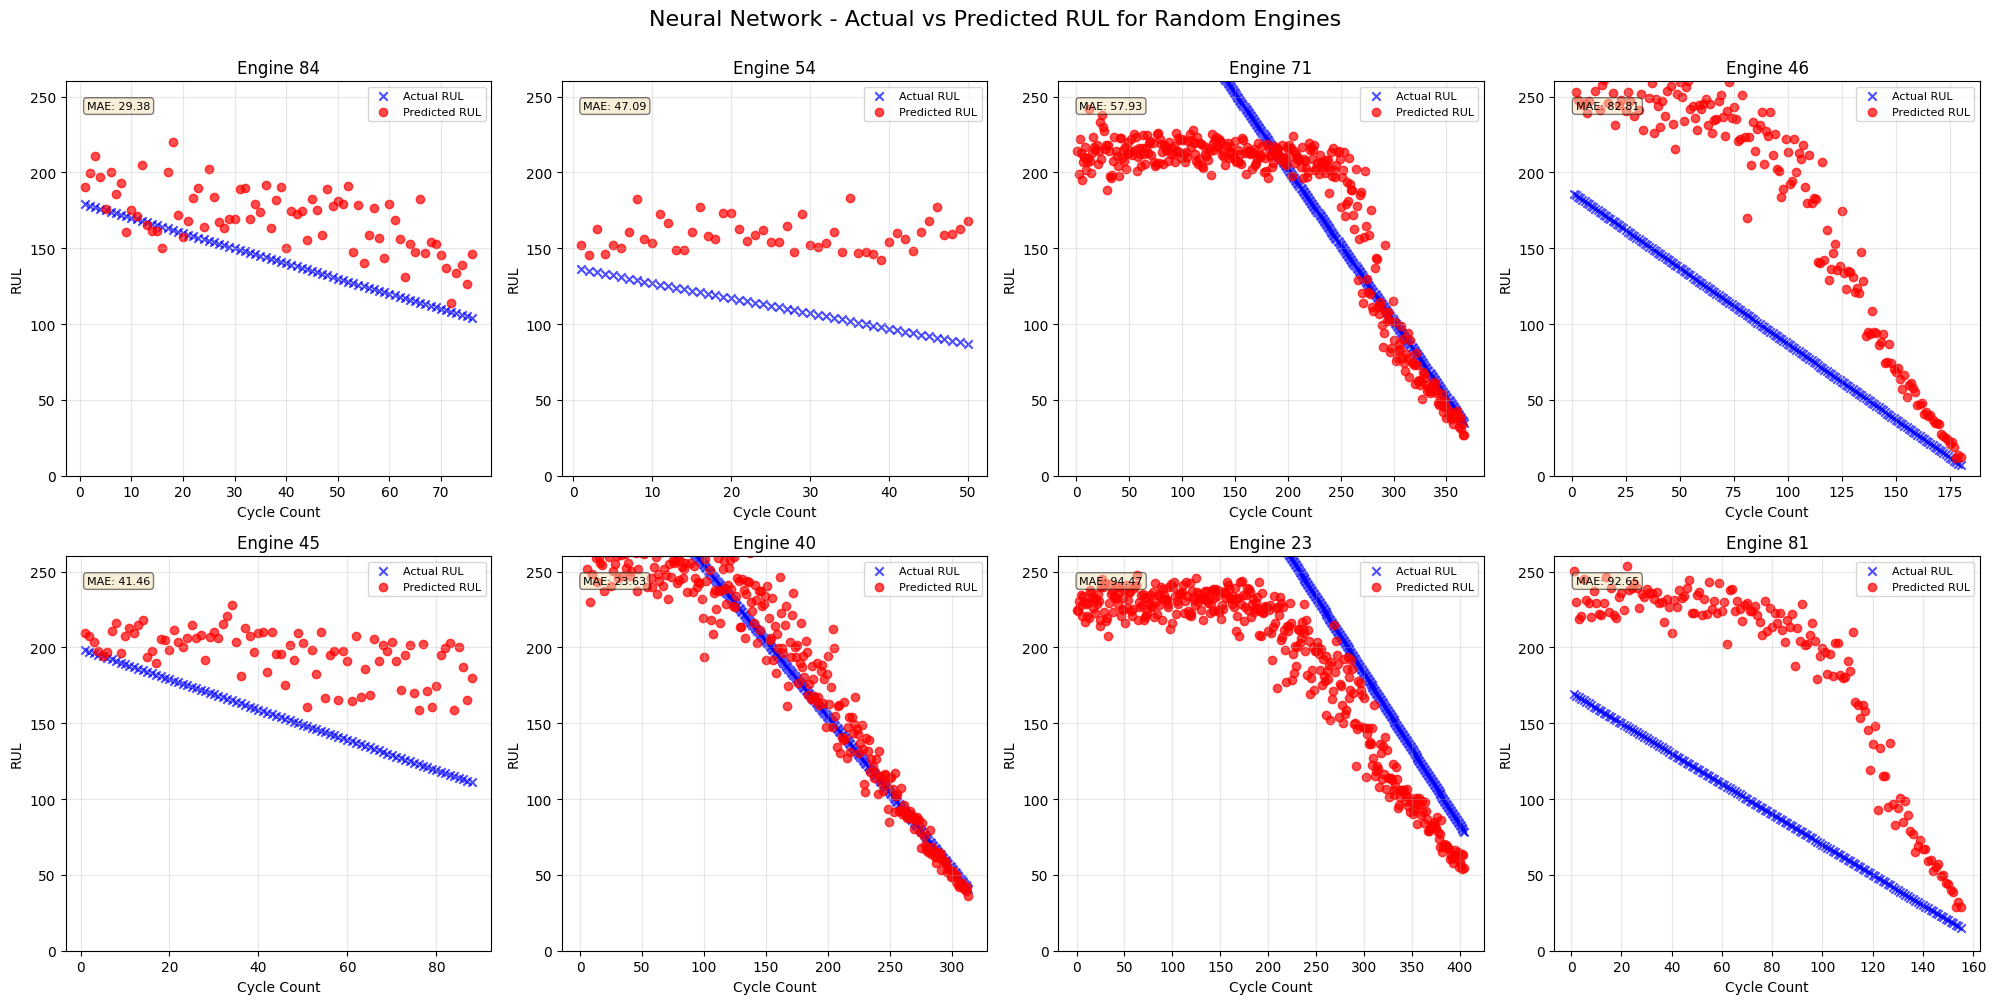

Summary Statistics for Selected Engines:
Engine 84: MAE = 29.38 cycles, Avg Error = 22.09%
Engine 54: MAE = 47.09 cycles, Avg Error = 44.74%
Engine 71: MAE = 57.93 cycles, Avg Error = 22.44%
Engine 46: MAE = 82.81 cycles, Avg Error = 93.88%
Engine 45: MAE = 41.46 cycles, Avg Error = 29.44%
Engine 40: MAE = 23.63 cycles, Avg Error = 10.42%
Engine 23: MAE = 94.47 cycles, Avg Error = 30.24%
Engine 81: MAE = 92.65 cycles, Avg Error = 117.50%


In [19]:
# Generate predictions for all test data
model.eval()
with torch.no_grad():
    y_predictions = model.forward(X_test).squeeze().numpy()

# Get unique engines and randomly select 8
unique_engines = Testing_df['engine'].unique()
np.random.seed(42)  # For reproducibility
selected_engines = np.random.choice(unique_engines, size=min(8, len(unique_engines)), replace=False)

# Create a figure with 8 subplots (2 rows x 4 columns)
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
fig.suptitle('Neural Network - Actual vs Predicted RUL for Random Engines', fontsize=16, y=1.00)

# Flatten axes array for easier iteration
axes = axes.flatten()

# Plot each selected engine
for idx, engine_num in enumerate(selected_engines):
    # Filter for current engine
    engine_mask = Testing_df['engine'] == engine_num
    engine_df = Testing_df[engine_mask]
    
    # Extract cycle data and RUL values
    X_og = engine_df['cycle'].values
    Y_og = engine_df['RUL'].values
    
    # Get predictions for current engine
    y_pred_engine = y_predictions[engine_mask]
    
    # Plot on the corresponding subplot
    axes[idx].scatter(X_og, Y_og, label='Actual RUL', color='blue', alpha=0.7, marker='x')
    axes[idx].scatter(X_og, y_pred_engine, label='Predicted RUL', color='red', alpha=0.7)
    axes[idx].set_title(f'Engine {engine_num}')
    axes[idx].set_xlabel('Cycle Count')
    axes[idx].set_ylabel('RUL')
    axes[idx].set_ylim(0, 260)  # Set y-axis limits from 0 to 260
    axes[idx].legend(fontsize=8)
    axes[idx].grid(True, alpha=0.3)
    
    # Calculate and display MAE for this engine
    mae_engine = np.mean(np.abs(Y_og - y_pred_engine))
    axes[idx].text(0.05, 0.95, f'MAE: {mae_engine:.2f}', 
                   transform=axes[idx].transAxes, 
                   verticalalignment='top',
                   bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5),
                   fontsize=8)

plt.tight_layout()
plt.show()

# Print summary statistics for all selected engines
print("Summary Statistics for Selected Engines:")
print("="*60)
for engine_num in selected_engines:
    engine_mask = Testing_df['engine'] == engine_num
    Y_og = Testing_df[engine_mask]['RUL'].values
    y_pred_engine = y_predictions[engine_mask]
    
    mae = np.mean(np.abs(Y_og - y_pred_engine))
    errors = (Y_og - y_pred_engine) / Y_og * 100
    avg_error = np.mean(np.abs(errors))
    
    print(f"Engine {engine_num}: MAE = {mae:.2f} cycles, Avg Error = {avg_error:.2f}%")


8 Engines with lowest final RUL:
  Engine 82: Final RUL = 6.0
  Engine 46: Final RUL = 7.0
  Engine 39: Final RUL = 8.0
  Engine 99: Final RUL = 8.0
  Engine 24: Final RUL = 9.0
  Engine 94: Final RUL = 10.0
  Engine 26: Final RUL = 11.0
  Engine 50: Final RUL = 11.0


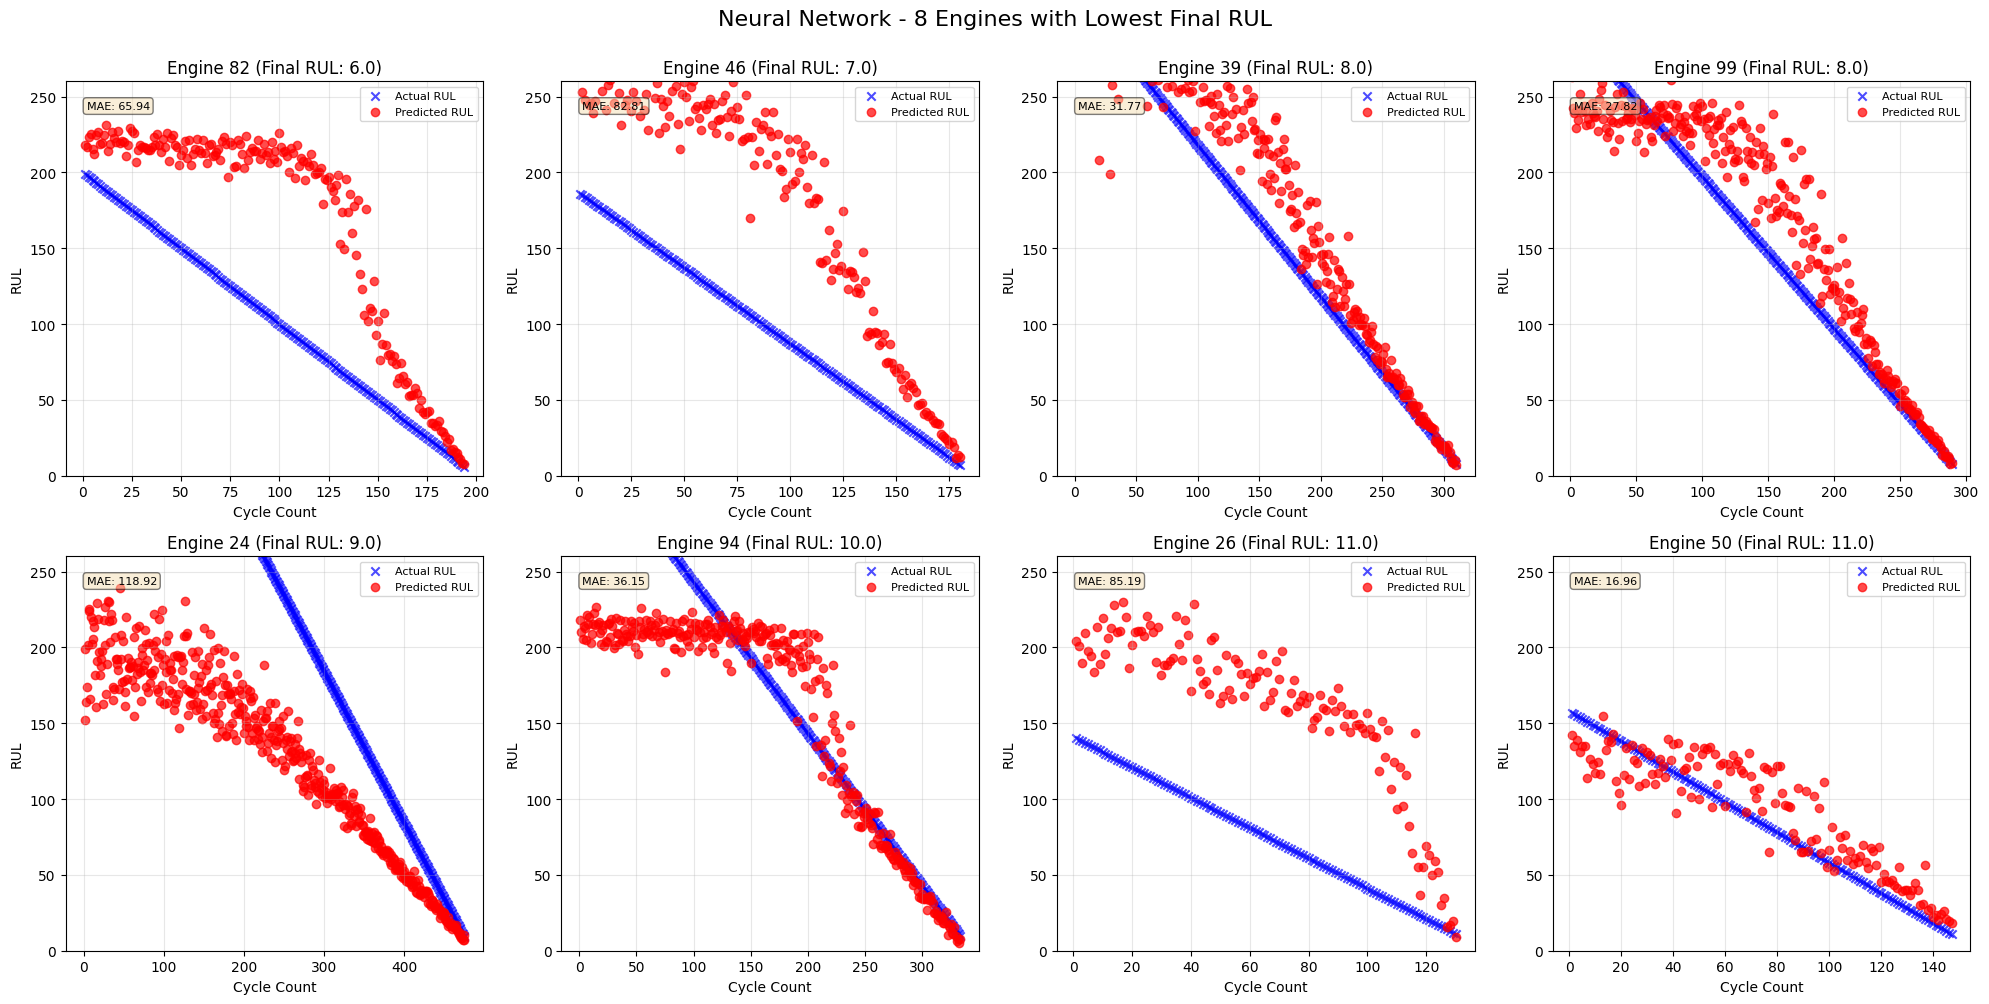


Summary Statistics for 8 Engines with Lowest Final RUL:
Engine 82 (Final RUL: 6.0): MAE = 65.94 cycles, Avg Error = 76.92%
Engine 46 (Final RUL: 7.0): MAE = 82.81 cycles, Avg Error = 93.88%
Engine 39 (Final RUL: 8.0): MAE = 31.77 cycles, Avg Error = 19.28%
Engine 99 (Final RUL: 8.0): MAE = 27.82 cycles, Avg Error = 20.32%
Engine 24 (Final RUL: 9.0): MAE = 118.92 cycles, Avg Error = 44.44%
Engine 94 (Final RUL: 10.0): MAE = 36.15 cycles, Avg Error = 18.17%
Engine 26 (Final RUL: 11.0): MAE = 85.19 cycles, Avg Error = 139.16%
Engine 50 (Final RUL: 11.0): MAE = 16.96 cycles, Avg Error = 27.14%


In [20]:
# Generate predictions for engines with the 8 lowest final RUL values
model.eval()
with torch.no_grad():
    y_predictions = model.forward(X_test).squeeze().numpy()

# Get final RUL for each engine and sort to find the 8 lowest
engine_final_rul = []
for engine_num in Testing_df['engine'].unique():
    engine_data = Testing_df[Testing_df['engine'] == engine_num]
    last_rul = engine_data['RUL'].iloc[-1]  # Get the last RUL value
    engine_final_rul.append((engine_num, last_rul))

# Sort by final RUL (ascending) and select the 8 engines with lowest final RUL
engine_final_rul.sort(key=lambda x: x[1])
selected_engines = [engine_num for engine_num, _ in engine_final_rul[:8]]

print(f"8 Engines with lowest final RUL:")
for engine_num, final_rul in engine_final_rul[:8]:
    print(f"  Engine {engine_num}: Final RUL = {final_rul:.1f}")

# Create a figure with 8 subplots (2 rows x 4 columns)
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
fig.suptitle('Neural Network - 8 Engines with Lowest Final RUL', fontsize=16, y=1.00)

# Flatten axes array for easier iteration
axes = axes.flatten()

# Plot each selected engine
for idx, engine_num in enumerate(selected_engines):
    # Filter for current engine
    engine_mask = Testing_df['engine'] == engine_num
    engine_df = Testing_df[engine_mask]
    
    # Extract cycle data and RUL values
    X_og = engine_df['cycle'].values
    Y_og = engine_df['RUL'].values
    
    # Get predictions for current engine
    y_pred_engine = y_predictions[engine_mask]
    
    # Get final RUL value
    final_rul = Y_og[-1]
    
    # Plot on the corresponding subplot
    axes[idx].scatter(X_og, Y_og, label='Actual RUL', color='blue', alpha=0.7, marker='x')
    axes[idx].scatter(X_og, y_pred_engine, label='Predicted RUL', color='red', alpha=0.7)
    axes[idx].set_title(f'Engine {engine_num} (Final RUL: {final_rul:.1f})')
    axes[idx].set_xlabel('Cycle Count')
    axes[idx].set_ylabel('RUL')
    axes[idx].set_ylim(0, 260)  # Set y-axis limits from 0 to 260
    axes[idx].legend(fontsize=8)
    axes[idx].grid(True, alpha=0.3)
    
    # Calculate and display MAE for this engine
    mae_engine = np.mean(np.abs(Y_og - y_pred_engine))
    axes[idx].text(0.05, 0.95, f'MAE: {mae_engine:.2f}', 
                   transform=axes[idx].transAxes, 
                   verticalalignment='top',
                   bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5),
                   fontsize=8)

plt.tight_layout()
plt.show()

# Print summary statistics for all selected engines
print("\nSummary Statistics for 8 Engines with Lowest Final RUL:")
print("="*60)
for engine_num in selected_engines:
    engine_mask = Testing_df['engine'] == engine_num
    engine_df = Testing_df[engine_mask]
    Y_og = engine_df['RUL'].values
    y_pred_engine = y_predictions[engine_mask]
    final_rul = Y_og[-1]
    
    mae = np.mean(np.abs(Y_og - y_pred_engine))
    errors = (Y_og - y_pred_engine) / Y_og * 100
    avg_error = np.mean(np.abs(errors))
    
    print(f"Engine {engine_num} (Final RUL: {final_rul:.1f}): MAE = {mae:.2f} cycles, Avg Error = {avg_error:.2f}%")
